# Dataset Deteccion De Objetos

En este cuaderno se detalla el dataset empleado para entrenar el modelo de detección de objetos. El objetivo es poder entrenar un modelo capaz de, dada una imagen, marcar el balón, los jugadores y los árbitros.

El marcado se realizará mediante Bounding Boxes (BB)

## Dataset SoccerNet

SoccerNet ofrece un dataset con imagenes marcadas. 

Realmente se tratan de clips de 30 segundos; cada uno de ellos a 25 FPS. En consecuencia, cada clip proporciona $ 30 \cdot 25 = 750 $ imagenes.

Todas las imagenes tiene una resolución de $1920$ x $ 1080$ pixeles en formato JPG

El dataset está dividido en Train y Test:

Train:

-  57 clips que equivalen a  $57 \cdot (30 \cdot 25) = 42.750$ imagenes

Test:

- 49 clips que equivalen a  $49 \cdot (30 \cdot 25) = 36.750$ imagenes

    
#### Formato Original

Cada clip está compuesto por 2 carpetas y 2 archivos.

Carpetas:
- img1: Contiene las $750$ imagenes enumeradas del 000001 al 000750
- det: Contiene un archivo llamado det.txt en formato csv con información relativa al marcado de los objetos de TODAS las imagenes. Cada linea tiene el siguiente formato:


    - \<Frame ID, Track ID, Coordenada X Esquina Superior Izquierda del BB, Coordenada Y Esquina Superior Izquierda del BB\, Acho del BB, Alto del BB, 1, -1, -1, -1>

        - Frame ID: número de imagen
        - Track ID: número que representa el tipo de objeto

    
Archivos:

- gameinfo.ini: Contiene información relativa al partido y, en particular, la relación Track_ID \<--\> Objeto
- seqinfo.ini: Contiene información relativa al clip
    - Frame rate
    - Número de imagenes totales que conforman el clip
    - Extensión de las imagenes
    - Resolución de las imagenes



In [3]:
SOCCERNET_PATH = "soccernet_dataset" #Ruta al dataset original
TRAIN_PATH = f'{SOCCERNET_PATH}/train'
TEST_PATH= f'{SOCCERNET_PATH}/test'

Mostramos una imagen  y su correspondiente marcado:

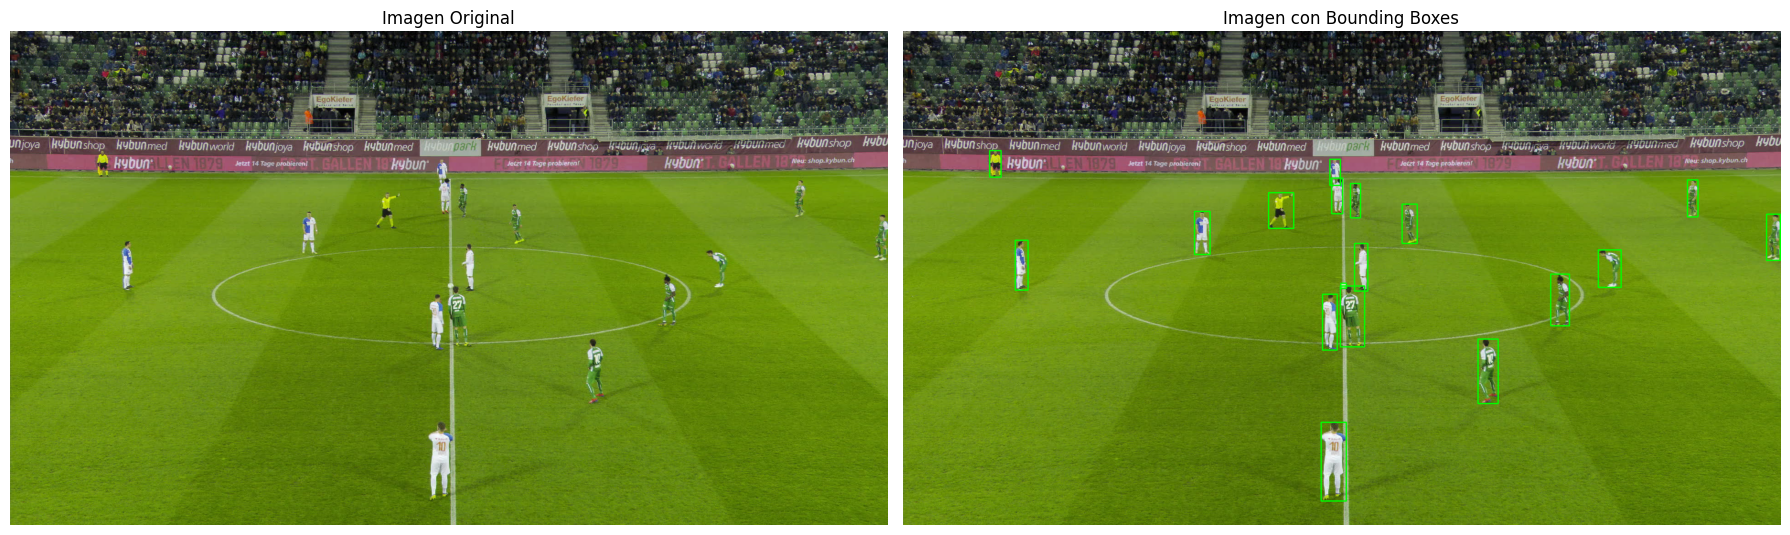

In [ ]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd

#Rutas
clip_path = f'{TRAIN_PATH}/SNMOT-060' #Ruta a un clip
img_path = f'{clip_path}/img1/000001.jpg' #Imagen 1 del clip SNMOT-060
det_info_path = f'{clip_path}/det/det.txt' #Ruta al .txt con las marcaciones

#Obtenemos relacion TRACK_ID <-> Tipo Objeto

img = cv2.imread(img_path)
img_bb = img.copy()

#Marcamos los Bounding Boxes
det_info = pd.read_csv(det_info_path,header=None)

for idx, row in det_info.iterrows():
    frame_id = int(row.iloc[0])
    if frame_id != 1:
        break

    x, y, w, h = int(row.iloc[2]), int(row.iloc[3]), int(row.iloc[4]), int(row.iloc[5]) #iloc selecciona el elemento en la pos n
    color = (0, 255, 0)  # verde
    cv2.rectangle(img_bb, (x, y), (x + w, y + h), color, 2)
        
    
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img_bb, cv2.COLOR_BGR2RGB)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Mostrar primera imagen
axes[0].imshow(img1)
axes[0].set_title("Imagen Original")
axes[0].axis("off")

# Mostrar segunda imagen
axes[1].imshow(img2)
axes[1].set_title("Imagen con Bounding Boxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()



#### Formato YOLO

Uno de los modelos que usaremos para la detección de objetos será YOLO (You Only Look Once) y para ello necesitamos cambiar el formato de las etiquetas.

YOLO requiere tener para cada conjunto de imagenes (Train, test o val) tener 2 carpetas:

- images: carpeta que contiene las imagenes
- labels: carpeta que contiene los archivos de anotaciones correspondientes a cada imagen

    - Hay tantos archivos como imagenes y con el mismo nombre que la imagen
    - Cada archivo es un .txt con el siguiente formato:
        - <class_id> <x_center> <y_center> \<ancho\> \<altura\>
            - class_id : un entero que representa la clase de objeto
            - x_center, y_center, ancho y altura: coordenadas NORMALIZADAS del BB  


Creamos una función que convierte el formato de SoccerNet al Formato YOLO:

In [39]:
WIDTH = 1920
HEIGTH = 1080

def soccer_format_to_yolo(soccernet_row,track_id):
    frame_id = int(row.iloc[0])
    id = int(row.iloc[1])
        

    x, y, w, h = int(row.iloc[2]), int(row.iloc[3]), int(row.iloc[4]), int(row.iloc[5]) #iloc selecciona el elemento en la pos n
    x_center = (x + w/2) / WIDTH
    y_center = (y + h/2) / HEIGTH
    w_norm = w / WIDTH
    h_norm = h / HEIGTH


    yolo_line = f"{track_id[id]} {x_center} {y_center} {w_norm} {h_norm}"
    return yolo_line

In [ ]:
import os
import configparser

object_dict = {
    "ball": 0,
    "player": 1,
    "referee": 2
}


WIDTH = 1920
HEIGTH = 1080

config = configparser.ConfigParser()

def soccernet_format_to(folder,output_folder,format):
    clips = os.listdir(folder)

    for clip in clips:
        clip_path = f'{folder}/{clip}'
        gt_info_path= f'{clip_path}/gt/gt.txt'

        os.makedirs(f'{clip_path}/{output_folder}',exist_ok=True) #Creamos carpeta donde se almacenarán las etiquetas en formato YOLO


        #Extreamos del archivo  gameinfo.ini la relación TRACK_ID <---> Objeto 
        config.read(f'{clip_path}/gameinfo.ini')

        track_id = {}  #Diccionario TRACK_ID <---> Objeto 

        for key in config["Sequence"]:
            
            if key.lower().startswith("trackletid_"):
                id =  int(key.split("_")[1])  #número id

                #Filtramos el tipo de objeto
                object_type = config["Sequence"][key]
                object_type = object_type.split(";")[0].strip().lower() #Sepaaramos hasta el ; (ver gameinfo.ini)
                object_type = object_type.split()[0]

                if object_type not in {"ball","player","referee"}:
                    track_id[id] = 1
                else:
                    track_id[id] = object_dict[object_type]



        #Leemos del archivo det.txt todas las lineas que contienen los BB's
        det_info = pd.read_csv(gt_info_path,header=None)
        frames_dict = {}

        for idx, row in det_info.iterrows():
            frame_id = int(row.iloc[0])
            new_format = format(row)
            frames_dict.setdefault(frame_id, []).append(new_format)

        new_labels = f'{clip_path}/{output_folder}'

        for frame_id, lines in frames_dict.items():
            filename = f"{frame_id:06d}.txt"  # 
            path_out = os.path.join(new_labels, filename)
            with open(path_out, "w") as f:
                f.write("\n".join(lines))

In [38]:
import os
import configparser

object_dict = {
    "ball": 0,
    "player": 1,
    "referee": 2
}


WIDTH = 1920
HEIGTH = 1080

config = configparser.ConfigParser()
clips = os.listdir(TRAIN_PATH)

for clip in clips:
    clip_path = f'{TRAIN_PATH}/{clip}'
    gt_info_path= f'{clip_path}/gt/gt.txt'

    os.makedirs(f'{clip_path}/yolo_labels',exist_ok=True) #Creamos carpeta donde se almacenarán las etiquetas en formato YOLO


    #Extreamos del archivo  gameinfo.ini la relación TRACK_ID <---> Objeto 
    config.read(f'{clip_path}/gameinfo.ini')

    track_id = {}  #Diccionario TRACK_ID <---> Objeto 

    for key in config["Sequence"]:
        
        if key.lower().startswith("trackletid_"):
            id =  int(key.split("_")[1])  #número id

            #Filtramos el tipo de objeto
            object_type = config["Sequence"][key]
            object_type = object_type.split(";")[0].strip().lower() #Sepaaramos hasta el ; (ver gameinfo.ini)
            object_type = object_type.split()[0]

            if object_type not in {"ball","player","referee"}:
                track_id[id] = 1
            else:
                track_id[id] = object_dict[object_type]



    #Leemos del archivo det.txt todas las lineas que contienen los BB's
    det_info = pd.read_csv(gt_info_path,header=None)
    frames_dict = {}

    for idx, row in det_info.iterrows():
        frame_id = int(row.iloc[0])
        id = int(row.iloc[1])
        

        x, y, w, h = int(row.iloc[2]), int(row.iloc[3]), int(row.iloc[4]), int(row.iloc[5]) #iloc selecciona el elemento en la pos n

        x_center = (x + w/2) / WIDTH
        y_center = (y + h/2) / HEIGTH
        w_norm = w / WIDTH
        h_norm = h / HEIGTH


        yolo_line = f"{track_id[id]} {x_center} {y_center} {w_norm} {h_norm}"
        frames_dict.setdefault(frame_id, []).append(yolo_line)

    yolo_labels = f'{clip_path}/yolo_labels'

    for frame_id, lines in frames_dict.items():
        filename = f"{frame_id:06d}.txt"  # 
        path_out = os.path.join(yolo_labels, filename)
        with open(path_out, "w") as f:
            f.write("\n".join(lines))
        
            